I am Importing all of the Libraries I will be using in this project

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

I am loading my dataset and then checking that I have it, its shape, and that its correct

In [9]:
df = pd.read_csv("datasets/heart.csv")
print(df.shape)
df.head()

(1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


Checking for data types and missing values 

In [10]:
df.info()
print("\nMissing values:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


Just getting a look at the summary of statistics 

In [11]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


class balances (nearly perfectly balanced, 526 with disease and 499 without)

target
1    526
0    499
Name: count, dtype: int64


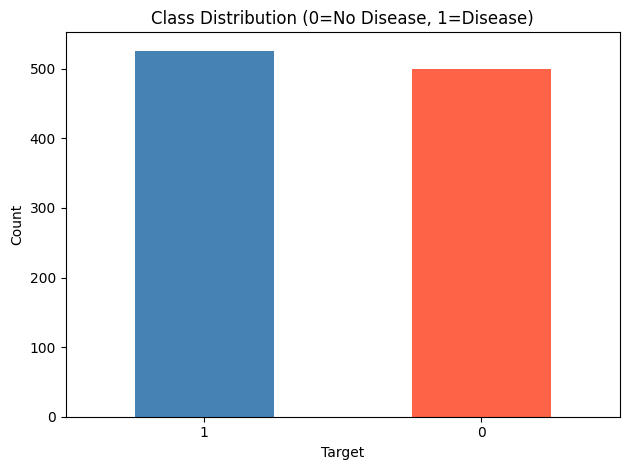

In [12]:
print(df['target'].value_counts())
df['target'].value_counts().plot(kind='bar', color=['steelblue','tomato'])
plt.title('Class Distribution (0=No Disease, 1=Disease)')
plt.xlabel('Target')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Seperating features and target

In [13]:
X = df.drop(columns=['target'])
y = df['target']
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1025, 13)
Target shape: (1025,)


train test split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (820, 13)
Test set size: (205, 13)


feature scaling 

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

running my first model logistic regression model 

In [16]:
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy: 0.7951219512195122


my second model Decision Tree

In [18]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.9853658536585366


third model random forest 

In [19]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))

Random Forest Accuracy: 0.9853658536585366


full metrics comparison for all 3 models

In [20]:
models = {
    'Logistic Regression': (lr_pred, 'LR'),
    'Decision Tree': (dt_pred, 'DT'),
    'Random Forest': (rf_pred, 'RF')
}

for name, (pred, _) in models.items():
    print(f"--- {name} ---")
    print(f"  Accuracy:  {accuracy_score(y_test, pred):.4f}")
    print(f"  Precision: {precision_score(y_test, pred):.4f}")
    print(f"  Recall:    {recall_score(y_test, pred):.4f}")
    print(f"  F1 Score:  {f1_score(y_test, pred):.4f}")
    print()

--- Logistic Regression ---
  Accuracy:  0.7951
  Precision: 0.7563
  Recall:    0.8738
  F1 Score:  0.8108

--- Decision Tree ---
  Accuracy:  0.9854
  Precision: 1.0000
  Recall:    0.9709
  F1 Score:  0.9852

--- Random Forest ---
  Accuracy:  0.9854
  Precision: 1.0000
  Recall:    0.9709
  F1 Score:  0.9852



confusion matrices for all 3 models

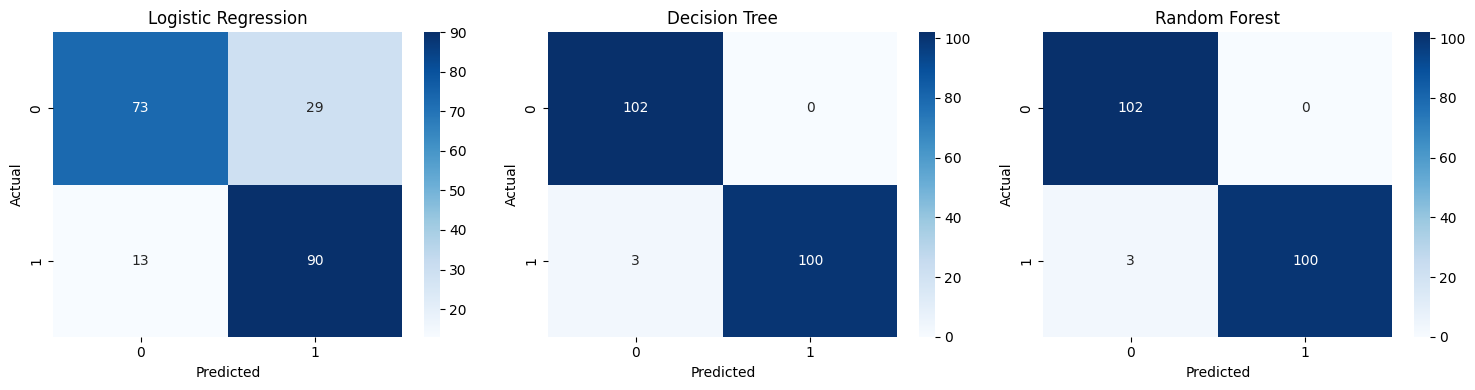

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, (pred, short)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

cross-validation (recall) for all 3 models

In [23]:
for name, model, Xdata in [
    ('Logistic Regression', lr_model, X_train_scaled),
    ('Decision Tree', dt_model, X_train),
    ('Random Forest', rf_model, X_train)
]:
    scores = cross_val_score(model, Xdata, y_train, cv=5, scoring='recall')
    print(f"{name}: mean recall = {scores.mean():.4f}, std = {scores.std():.4f}")

Logistic Regression: mean recall = 0.9007, std = 0.0306
Decision Tree: mean recall = 0.9788, std = 0.0319
Random Forest: mean recall = 0.9859, std = 0.0228


feature importance from Random Forest

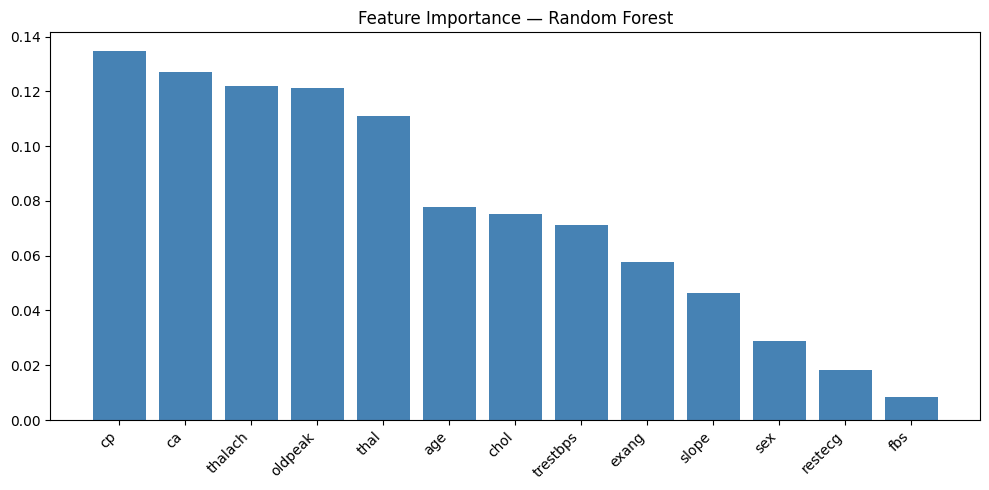

In [22]:
feature_names = X.columns
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(feature_names)), importances[indices], color='steelblue')
plt.xticks(range(len(feature_names)), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.title('Feature Importance — Random Forest')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Heart Disease Prediction — Technical Report

## Dataset & Problem Framing
For this project I used the Heart Disease dataset from Kaggle
(https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset),
which originally came from the UCI Machine Learning Repository. The
dataset has 1,025 patient records and 14 columns — 13 clinical features
and a binary target (0 = no heart disease, 1 = heart disease present).

My main research question was: can we predict whether a patient has
heart disease using routine clinical measurements, and if so, which
features matter most?

The features cover things you'd actually see in a doctor's visit —
age, sex, chest pain type, resting blood pressure, cholesterol, max
heart rate during exercise, and a few others. That made this dataset
feel worth exploring because the results could connect to something
real.

## Data Preprocessing & Assumptions
The first thing I did was check for missing values and was surprised
to find there were none — all 1,025 rows were complete. That meant I
didn't have to make any decisions about imputation, which simplified
things.

I also checked the class balance early on, which our class demo
taught me matters a lot. The split was 526 positive cases (51.3%)
vs 499 negative (48.7%) — nearly 50/50, so I didn't need to do any
resampling or adjust for imbalance.

For the train/test split I went with the standard 80/20 split from
class (820 training, 205 test), and set random_state=42 so my results
are reproducible.

One preprocessing decision I had to think about was feature scaling.
I used StandardScaler, but only for Logistic Regression. The reason
is that Logistic Regression is sensitive to the scale of features —
thalach (max heart rate) goes up to around 202 while fbs (fasting
blood sugar) is just 0 or 1, so without scaling the model would
weight them unfairly. Decision Tree and Random Forest don't have this
problem since they split on thresholds rather than distances, so I
left those with the original values.

## Model Experiments
I chose three models that build on each other in complexity, which
made it easier to compare results and explain the differences.

**Model 1 — Logistic Regression:** I used this as my baseline because
it's the simplest classification model we covered and it's easy to
interpret. It assumes a linear relationship between the features and
the outcome, which I suspected might be a limitation given how
complex heart disease actually is. I set max_iter=1000 to make sure
the model had enough iterations to converge.

**Model 2 — Decision Tree:** I chose this next because it can pick up
on non-linear patterns that Logistic Regression would miss. It works
by splitting the data on feature thresholds, and it's also easy to
visualize and explain. I kept the default parameters and just set
random_state=42.

**Model 3 — Random Forest:** This was my most complex model — it
builds 100 decision trees and averages their predictions, which
reduces the variance you get from a single tree. I also chose it
because it gives you feature importances directly, which connects
back to my research question about which features matter most.

## Model Evaluation & Interpretation

The jump from Logistic Regression to the tree-based models was bigger
than I expected. Going from 80% to 98.5% accuracy suggests the
relationships in this data aren't linear — which makes sense
medically, since heart disease risk probably involves complex
interactions between multiple factors rather than each one
contributing independently.

Logistic Regression still did something interesting though: its
recall was 87.4%, meaning it caught most actual disease cases. But
it had 29 false positives — patients flagged as having disease who
didn't. For a medical context, that's worth caring about because
false positives cause unnecessary follow-up and patient stress.

Both tree models hit perfect precision (1.0), meaning every patient
they flagged as having heart disease actually did. That's a strong
result. Cross-validation backed this up too — Random Forest had a
mean recall of 98.6% with a standard deviation of just 0.023 across
5 folds, which tells me the model isn't just getting lucky on one
particular split.

The feature importance plot from Random Forest showed that chest pain
type (cp) was the most predictive feature, followed by number of
major vessels (ca), max heart rate (thalach), ST depression
(oldpeak), and thalassemia type (thal). I found it interesting that
chest pain type ranked first — it makes clinical sense because
different types of chest pain are directly associated with cardiac
events. The fact that fbs (fasting blood sugar) and restecg ranked
lowest also aligns with what I'd expect, since those are less
specific indicators.

## Limitations, Ethics & Reflection
A few things I'd flag about this project. First, the near-perfect
accuracy from the tree models made me a little suspicious — the
dataset might be too small or too clean to fully reflect real-world
messiness. With only 1,025 records from one source (Cleveland Clinic),
it's hard to know how well this would generalize to patients from
different hospitals, age groups, or backgrounds.

There's also a demographic limitation worth naming: the dataset
encodes sex as a binary variable and almost certainly skews toward
certain populations. A model trained on this data could perform
worse on groups that weren't well represented.

Most importantly, this is not a diagnostic tool. Even a 98.5%
accurate model gets things wrong, and in medicine, those errors
have real consequences. This kind of model should only ever assist
a doctor's decision, not replace it.

If I had more time, I'd want to test the model on a completely
separate external dataset to see if the performance holds, and I'd
explore hyperparameter tuning with GridSearchCV to see whether the
Decision Tree could be improved or was already overfitting.

## References & AI Transparency
- Dataset: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset
- Libraries: pandas, numpy, matplotlib, seaborn, scikit-learn
- Claude was used to assist with project planning, code 
  structure guidance/syntax, and help writing Portfolio and Technical Report feedback.